# 🌸 EDA - Phân Tích Dữ Liệu Iris Dataset

**Môn:** Machine Learning  
**Bài toán:** Multiclass Classification – Phân loại 3 loại hoa Iris  
**Dataset:** iris.csv  
**4 features | 150 mẫu | 3 classes**

## 1. Định nghĩa vấn đề

- Phân loại hoa Iris thành 3 lớp:
  - Iris-setosa
  - Iris-versicolor
  - Iris-virginica

- Input: 4 đặc trưng (sepal, petal)
- Output: nhãn 3 lớp

- Bài toán: multiclass classification


# 2. Chuẩn bị vấn đề

## 2.1. Khai báo thư viện & Tham số thực nghiệm

Toàn bộ tham số thực nghiệm được khai báo tập trung ở đây để dễ thay đổi.
`DATA_NAME` là tên file CSV đặt trong thư mục `data/` — chỉ cần đổi tên này là pipeline tự cập nhật
các đường dẫn còn lại. Sáu file CSV đầu ra (3 scaler × 2 tập) sẽ được lưu vào `exps_/` và
dùng làm đầu vào cho `02_train.ipynb`.

Dữ liệu được chia 70% train / 30% test với `stratify=y` để đảm bảo tỉ lệ các lớp
trong train và test phản ánh đúng phân phối gốc — đặc biệt quan trọng khi dữ liệu mất cân bằng.
`random_state` cố định để kết quả tái hiện được qua các lần chạy.

In [1]:
# ── Thư viện ────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from datetime import datetime
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# ── Tham số thực nghiệm ─────────────────────────────────
# ============================================================
# NHẬP TÊN DATA Ở ĐÂY (không có đuôi .csv)
DATA_NAME = 'iris' # tên của bộ dữ liệu cần trích xuất
# ============================================================

BASE_DIR   = os.path.abspath(os.path.join(os.getcwd(), '..')) \
             if os.path.basename(os.getcwd()) == 'prj' \
             else os.getcwd()

DATA_PATH  = os.path.join(BASE_DIR, 'data', f'{DATA_NAME}.csv')
OUTPUT_DIR = os.path.join(BASE_DIR, 'exps_')
os.makedirs(OUTPUT_DIR, exist_ok=True)

COL_NAMES = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
FEATURES  = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
TEST_SIZE    = 0.30 # tỉ lệ test
RANDOM_STATE = 42 # cố định hạt giống ngẫu nhiên

# ── Đường dẫn file output ───────────────────────────────
# cấu trúc tên file output là: [tên bộ dữ liệu input]_[train/test]_[raw/minmax/standard].csv
EDA_LOG         = os.path.join(OUTPUT_DIR, f'{DATA_NAME}_eda_log.xlsx')
TRAIN_DATA_RAW  = os.path.join(OUTPUT_DIR, f'{DATA_NAME}_train_raw.csv')
TEST_DATA_RAW   = os.path.join(OUTPUT_DIR, f'{DATA_NAME}_test_raw.csv')
TRAIN_DATA_MM   = os.path.join(OUTPUT_DIR, f'{DATA_NAME}_train_minmax.csv')
TEST_DATA_MM    = os.path.join(OUTPUT_DIR, f'{DATA_NAME}_test_minmax.csv')
TRAIN_DATA_STD  = os.path.join(OUTPUT_DIR, f'{DATA_NAME}_train_standard.csv')
TEST_DATA_STD   = os.path.join(OUTPUT_DIR, f'{DATA_NAME}_test_standard.csv')
# Ghi chú: 6 file CSV trên là đầu ra của bước EDA, được dùng làm đầu vào cho 02_train.ipynb

'''
Nội dung các file lưu lại từng lần chạy EDA:
1. eda_log.xlsx: gồm 5 sheet:
   + Thong_tin_chung  : ngày chạy, số dòng, cột, lớp, missing, duplicates.
   + Thong_ke_mo_ta   : min, max, mean, std từng feature.
   + Missing_Values   : số lượng và % giá trị thiếu từng cột.
   + Phan_phoi_lop    : mỗi lớp bao nhiêu mẫu, chiếm bao nhiêu %.
   + Train_Test_Split : đường dẫn 6 file csv, số mẫu train/test.
2. [name_data_input]_train_raw.csv      : data train chưa chuẩn hóa.
3. [name_data_input]test_raw.csv       : data test chưa chuẩn hóa.
4. [name_data_input]train_minmax.csv   : data train đã chuẩn hóa MinMax.
5. [name_data_input]test_minmax.csv    : data test đã chuẩn hóa MinMax.
6. [name_data_input]train_standard.csv : data train đã chuẩn hóa Standard.
7. [name_data_input]test_standard.csv  : data test đã chuẩn hóa Standard.
'''

print('✅ Khai báo thư viện và tham số xong!')
print(f'   DATA_NAME  : {DATA_NAME}')
print(f'   BASE_DIR   : {BASE_DIR}')
print(f'   DATA_PATH  : {DATA_PATH}')
print(f'   OUTPUT_DIR : {OUTPUT_DIR}')
print(f'   Test size  : {TEST_SIZE:.0%}')
print(f'   Random seed: {RANDOM_STATE}')

✅ Khai báo thư viện và tham số xong!
   DATA_NAME  : iris
   BASE_DIR   : D:\final-project-CSTTNT-\irisClassification
   DATA_PATH  : D:\final-project-CSTTNT-\irisClassification\data\iris.csv
   OUTPUT_DIR : D:\final-project-CSTTNT-\irisClassification\exps_
   Test size  : 30%
   Random seed: 42


# 3. Phân tích dữ liệu

## 3.1. Thống kê mô tả về dữ liệu

### 3.1.1 Kích thước dữ liệu

Dữ liệu được đọc từ file CSV không có header — tên cột được gán thủ công theo danh sách
`COL_NAMES` đã khai báo ở trên. Kiểm tra shape và 5 dòng đầu để xác nhận dữ liệu tải đúng.

In [2]:
df = pd.read_csv(DATA_PATH, header=None, names=COL_NAMES)

print(f'Shape: {df.shape}  ({df.shape[0]} dòng x {df.shape[1]} cột)')
print(f'Tên cột (5 đầu + label): {COL_NAMES[:5]} ... {COL_NAMES[-1]}')
df.head(5)


Shape: (150, 5)  (150 dòng x 5 cột)
Tên cột (5 đầu + label): ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class'] ... class


,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### 3.1.2. Kiểu dữ liệu của từng thuộc tính

In [3]:
print('=== THÔNG TIN DATASET ===')
df.info()

=== THÔNG TIN DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### 3.1.3. Thống kê mô tả

In [4]:
print('=== THỐNG KÊ MÔ TẢ (10 feature đầu) ===')
df[FEATURES[:10]].describe().round(4)
# thêm cái cuối

=== THỐNG KÊ MÔ TẢ (10 feature đầu) ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.0000,150.0000,150.0000,150.0000
mean,5.8433,3.0540,3.7587,1.1987
std,0.8281,0.4336,1.7644,0.7632
min,4.3000,2.0000,1.0000,0.1000
25%,5.1000,2.8000,1.6000,0.3000
50%,5.8000,3.0000,4.3500,1.3000
75%,6.4000,3.3000,5.1000,1.8000
max,7.9000,4.4000,6.9000,2.5000


### 3.1.4. Kiểm tra Missing Values & Duplicates

In [5]:
print('=== MISSING VALUES ===')
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
df_missing  = pd.DataFrame({'Số thiếu': missing, '% thiếu': missing_pct})
print(df_missing[df_missing['Số thiếu'] > 0])
print(f'→ Tổng missing: {missing.sum()}')

print(f'\n=== DUPLICATES ===')
dup = df.duplicated().sum()
print(f'Số dòng trùng lặp: {dup}')
if dup > 0:
    print('⚠️  Có dòng trùng lặp!')
else:
    print('✅ Không có dòng trùng lặp')

=== MISSING VALUES ===
Empty DataFrame
Columns: [Số thiếu, % thiếu]
Index: []
→ Tổng missing: 0

=== DUPLICATES ===
Số dòng trùng lặp: 3
⚠️  Có dòng trùng lặp!


### 3.1.5. Phân phối nhãn (Class Distribution)

=== PHÂN PHỐI LỚP ===
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


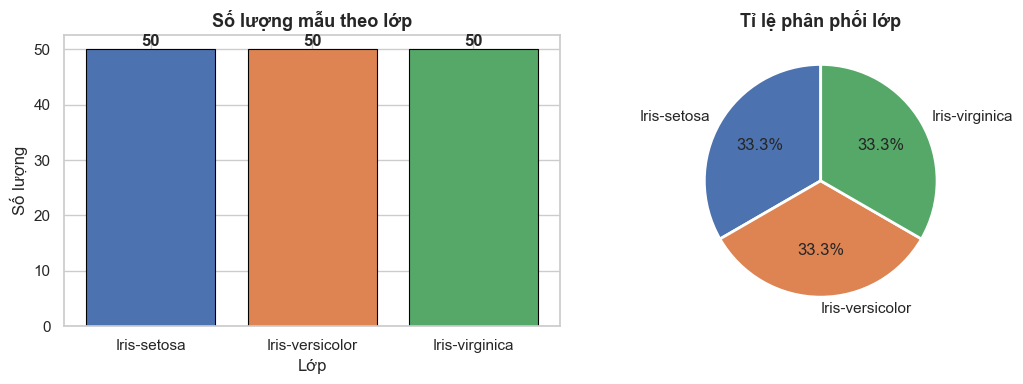

→ Dữ liệu cân bằng hoàn toàn: mỗi lớp 50 mẫu


In [6]:
class_counts = df['class'].value_counts()
print('=== PHÂN PHỐI LỚP ===')
print(class_counts)

colors = ['#4C72B0', '#DD8452', '#55A868']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
axes[0].bar(class_counts.index, class_counts.values,
            color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Số lượng mẫu theo lớp', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lớp')
axes[0].set_ylabel('Số lượng')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Tỉ lệ phân phối lớp', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_class_distribution.png'), bbox_inches='tight')
plt.show()
print(f'→ Dữ liệu cân bằng hoàn toàn: mỗi lớp {class_counts.values[0]} mẫu')

## 3.2. Hiển thị dữ liệu

### 3.2.1. Phân phối từng feature (Histogram Grid)

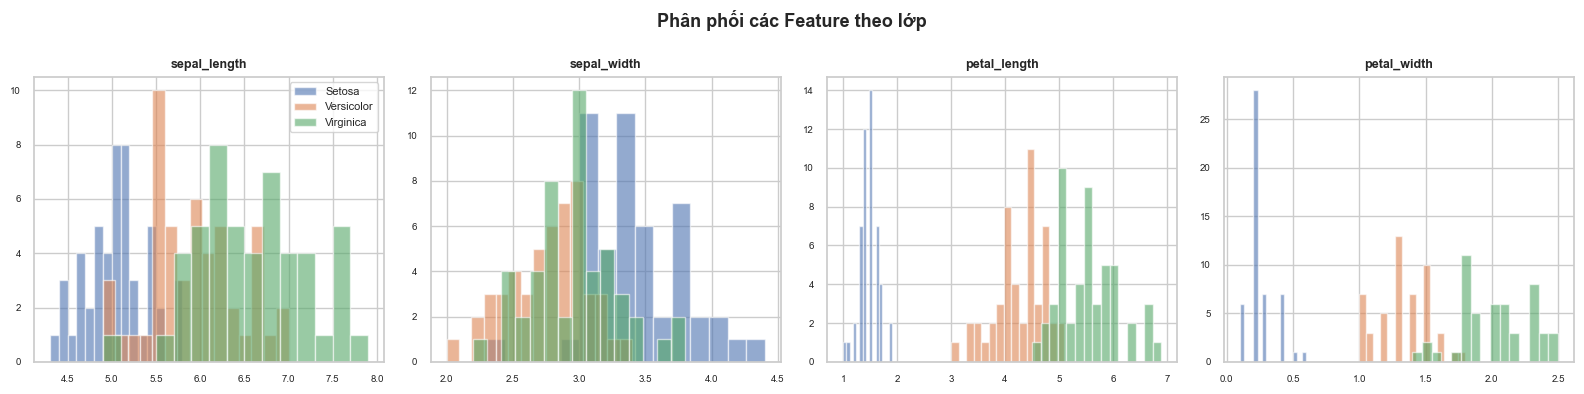

In [7]:
# Tách dữ liệu theo từng lớp để vẽ phân phối chồng lên nhau
df_setosa     = df[df['class'] == 'Iris-setosa'][FEATURES]
df_versicolor = df[df['class'] == 'Iris-versicolor'][FEATURES]
df_virginica  = df[df['class'] == 'Iris-virginica'][FEATURES]

palette_3 = {'Iris-setosa': '#4C72B0', 'Iris-versicolor': '#DD8452', 'Iris-virginica': '#55A868'}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(FEATURES):
    axes[i].hist(df_setosa[feat],     bins=15, alpha=0.6, label='Setosa',     color='#4C72B0', edgecolor='white')
    axes[i].hist(df_versicolor[feat], bins=15, alpha=0.6, label='Versicolor', color='#DD8452', edgecolor='white')
    axes[i].hist(df_virginica[feat],  bins=15, alpha=0.6, label='Virginica',  color='#55A868', edgecolor='white')
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)
axes[0].legend(fontsize=8)

plt.suptitle('Phân phối các Feature theo lớp', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_histogram.png'), bbox_inches='tight', dpi=100)
plt.show()

### 3.2.2. Boxplot - Phát hiện Outlier (sample features)

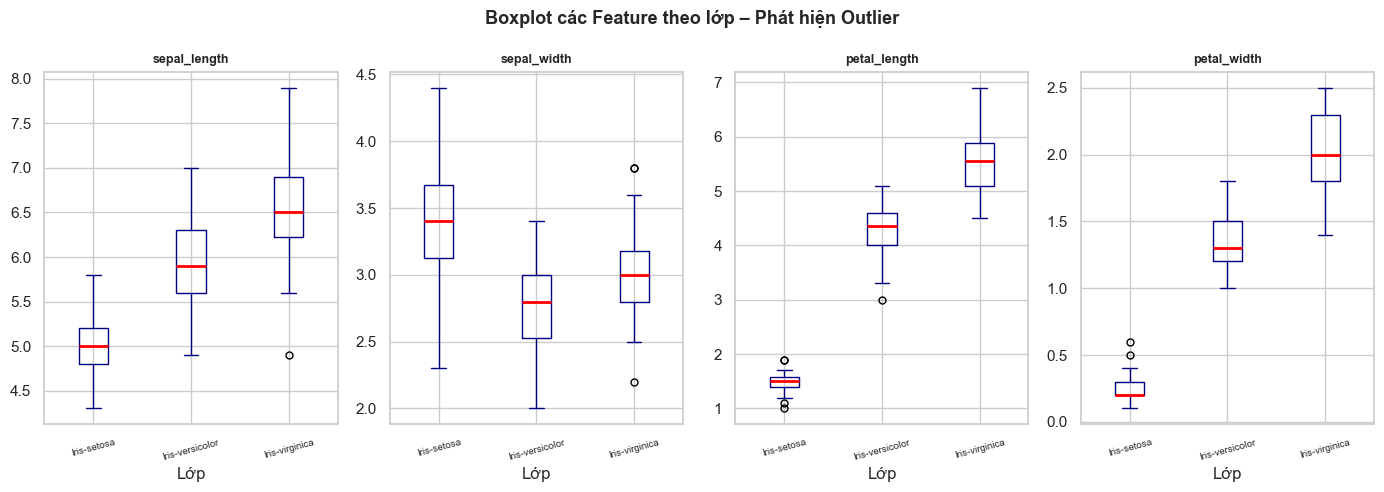

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for i, feat in enumerate(FEATURES):
    df.boxplot(column=feat, by='class', ax=axes[i],
               boxprops=dict(color='navy'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='navy'),
               capprops=dict(color='navy'),
               flierprops=dict(marker='o', color='orange', markersize=5))
    axes[i].set_title(feat, fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Lớp')
    axes[i].tick_params(axis='x', labelrotation=15, labelsize=7)

plt.suptitle('Boxplot các Feature theo lớp – Phát hiện Outlier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_boxplot.png'), bbox_inches='tight')
plt.show()

### 3.2.3. Violin Plot

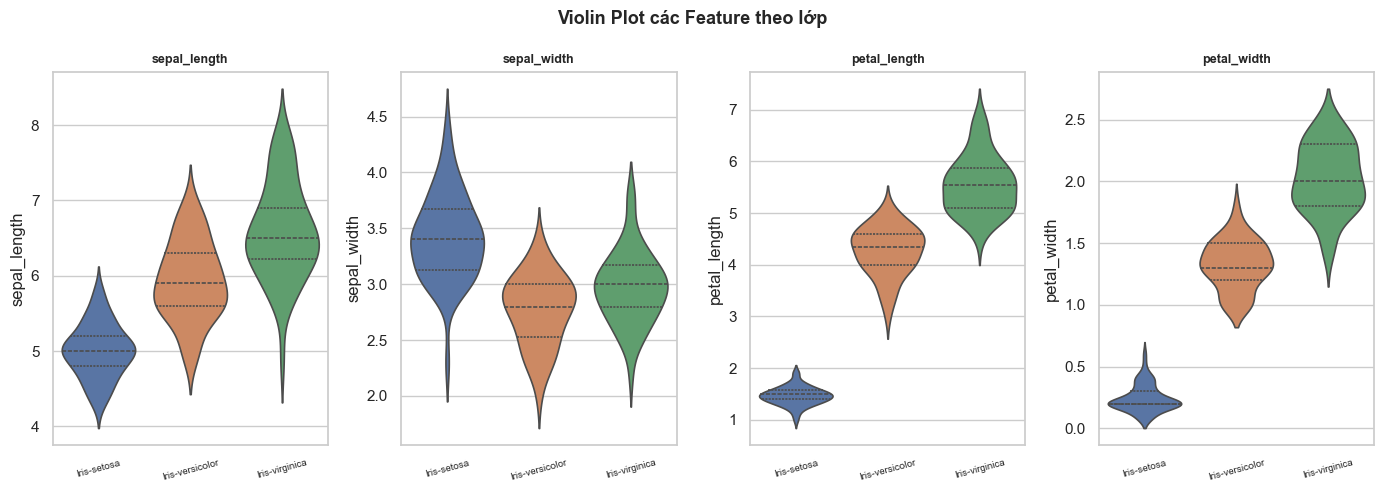

In [9]:
palette_cls = {'Iris-setosa': '#4C72B0', 'Iris-versicolor': '#DD8452', 'Iris-virginica': '#55A868'}

fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for i, feat in enumerate(FEATURES):
    sns.violinplot(data=df, x='class', y=feat, ax=axes[i],
                   palette=palette_cls, inner='quartile', linewidth=1.2)
    axes[i].set_title(feat, fontweight='bold', fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelrotation=15, labelsize=7)

plt.suptitle('Violin Plot các Feature theo lớp', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_violin.png'), bbox_inches='tight')
plt.show()

### 3.2.4. Giá trị trung bình từng Feature theo lớp

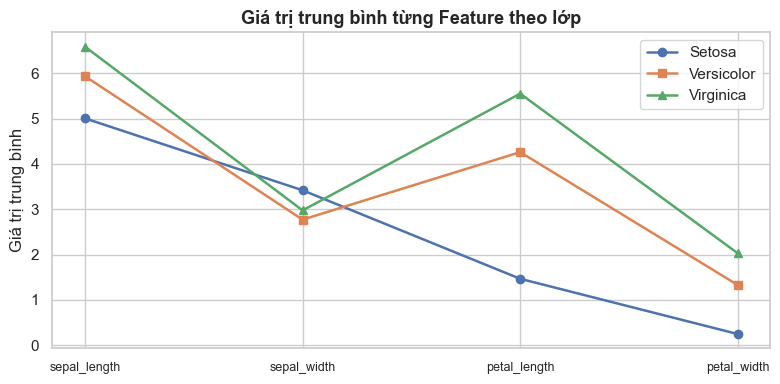

In [10]:
mean_setosa     = df_setosa.mean()
mean_versicolor = df_versicolor.mean()
mean_virginica  = df_virginica.mean()

x = np.arange(len(FEATURES))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, mean_setosa.values,     label='Setosa',     marker='o', ms=6, lw=1.8, color='#4C72B0')
ax.plot(x, mean_versicolor.values, label='Versicolor', marker='s', ms=6, lw=1.8, color='#DD8452')
ax.plot(x, mean_virginica.values,  label='Virginica',  marker='^', ms=6, lw=1.8, color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(FEATURES, fontsize=9)
ax.set_title('Giá trị trung bình từng Feature theo lớp', fontsize=13, fontweight='bold')
ax.set_ylabel('Giá trị trung bình')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_mean_by_class.png'), bbox_inches='tight')
plt.show()

### 3.2.5. Correlation Heatmap

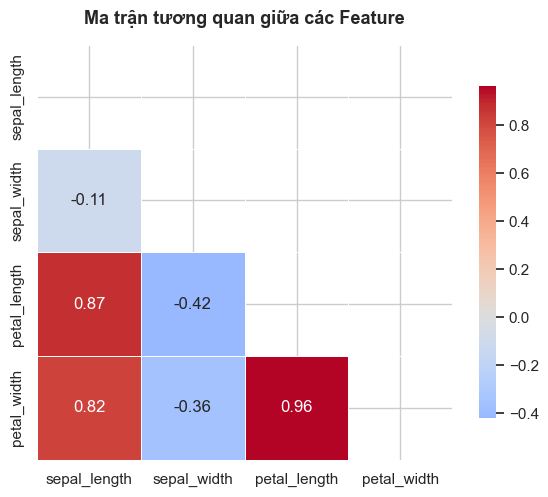


📌 Nhận xét:
  - Số cặp feature có |corr| > 0.9: 1
    petal_length ↔ petal_width: 0.963


In [11]:
corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax,
            annot=True, fmt='.2f',
            cbar_kws={'shrink': 0.8})
ax.set_title('Ma trận tương quan giữa các Feature', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_correlation.png'), bbox_inches='tight')
plt.show()

# Đếm cặp tương quan cao
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        v = abs(corr.iloc[i,j])
        if v > 0.9:
            high_corr.append((corr.columns[i], corr.columns[j], round(float(v),3)))
print(f'\n📌 Nhận xét:')
print(f'  - Số cặp feature có |corr| > 0.9: {len(high_corr)}')
for pair in high_corr:
    print(f'    {pair[0]} ↔ {pair[1]}: {pair[2]}')

# 4. Chuẩn bị dữ liệu

## 4.1. Kiểm tra phân phối chuẩn (Shapiro-Wilk)

Kiểm định Shapiro-Wilk kiểm tra từng feature có phân phối chuẩn không (p > 0.05 → chuẩn).
Kết quả này dùng để lựa chọn phương pháp chuẩn hóa phù hợp ở bước tiếp theo.
Với dữ liệu không phân phối chuẩn, StandardScaler vẫn hợp lệ vì nó chỉ dịch về mean=0, std=1
chứ không yêu cầu dữ liệu phải chuẩn.

In [12]:
print('=== KIỂM TRA PHÂN PHỐI CHUẨN (Shapiro-Wilk) ===')
normal_count = 0
for feat in FEATURES:
    _, p = stats.shapiro(df[feat])
    if p > 0.05:
        normal_count += 1

print(f'Features đạt phân phối chuẩn (p>0.05): {normal_count} / {len(FEATURES)}')
print(f'Features KHÔNG đạt phân phối chuẩn   : {len(FEATURES)-normal_count} / {len(FEATURES)}')
print('→ Đa số features không phân phối chuẩn → StandardScaler vẫn phù hợp để chuẩn hóa')

=== KIỂM TRA PHÂN PHỐI CHUẨN (Shapiro-Wilk) ===
Features đạt phân phối chuẩn (p>0.05): 1 / 4
Features KHÔNG đạt phân phối chuẩn   : 3 / 4
→ Đa số features không phân phối chuẩn → StandardScaler vẫn phù hợp để chuẩn hóa


## 4.2. Chia dữ liệu Train/Test (7/3)

In [13]:
print('=== CHIA DỮ LIỆU TRAIN / TEST (7/3) ===')

X = df[FEATURES]
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print(f'Tổng mẫu    : {len(df)}')
print(f'Train set   : {len(X_train)} mẫu ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test set    : {len(X_test)}  mẫu ({len(X_test)/len(df)*100:.0f}%)')
print(f'\nPhân phối train:\n{y_train.value_counts()}')
print(f'\nPhân phối test:\n{y_test.value_counts()}')

=== CHIA DỮ LIỆU TRAIN / TEST (7/3) ===
Tổng mẫu    : 150
Train set   : 105 mẫu (70%)
Test set    : 45  mẫu (30%)

Phân phối train:
class
Iris-versicolor    35
Iris-setosa        35
Iris-virginica     35
Name: count, dtype: int64

Phân phối test:
class
Iris-virginica     15
Iris-versicolor    15
Iris-setosa        15
Name: count, dtype: int64


## 4.3. Chuẩn hóa dữ liệu & Lưu file CSV

Hàm `save_split` thực hiện hai việc trong một lượt: chuẩn hóa dữ liệu (nếu có scaler)
rồi lưu ngay ra file CSV. Scaler chỉ được `fit` trên tập train và `transform` trên cả hai tập —
tập test không được tham gia fit để tránh data leakage.
Ba lượt gọi tương ứng với ba chiến lược: giữ nguyên (raw), MinMaxScaler, và StandardScaler.

In [14]:
def save_split(X_tr, X_te, y_tr, y_te, train_path, test_path, scaler=None, scaler_name='raw'):
    """Chuẩn hóa (nếu cần) và lưu file train/test"""
    X_tr_s, X_te_s = X_tr.copy(), X_te.copy()
    if scaler:
        X_tr_s = pd.DataFrame(scaler.fit_transform(X_tr), columns=FEATURES, index=X_tr.index)
        X_te_s = pd.DataFrame(scaler.transform(X_te),     columns=FEATURES, index=X_te.index)

    train_df = pd.concat([X_tr_s, y_tr], axis=1)
    test_df  = pd.concat([X_te_s, y_te], axis=1)
    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path,  index=False)
    print(f'✅ [{scaler_name:8s}] Train → {os.path.basename(train_path)}')
    print(f'✅ [{scaler_name:8s}] Test  → {os.path.basename(test_path)}')
    return train_df, test_df

# Raw
train_raw, test_raw = save_split(
    X_train, X_test, y_train, y_test,
    TRAIN_DATA_RAW, TEST_DATA_RAW, scaler_name='raw')

# MinMax
train_mm, test_mm = save_split(
    X_train, X_test, y_train, y_test,
    TRAIN_DATA_MM, TEST_DATA_MM,
    scaler=MinMaxScaler(), scaler_name='minmax')

# Standard
train_std, test_std = save_split(
    X_train, X_test, y_train, y_test,
    TRAIN_DATA_STD, TEST_DATA_STD,
    scaler=StandardScaler(), scaler_name='standard')

✅ [raw     ] Train → iris_train_raw.csv
✅ [raw     ] Test  → iris_test_raw.csv
✅ [minmax  ] Train → iris_train_minmax.csv
✅ [minmax  ] Test  → iris_test_minmax.csv
✅ [standard] Train → iris_train_standard.csv
✅ [standard] Test  → iris_test_standard.csv


## 4.4. So sánh phân phối trước/sau chuẩn hóa

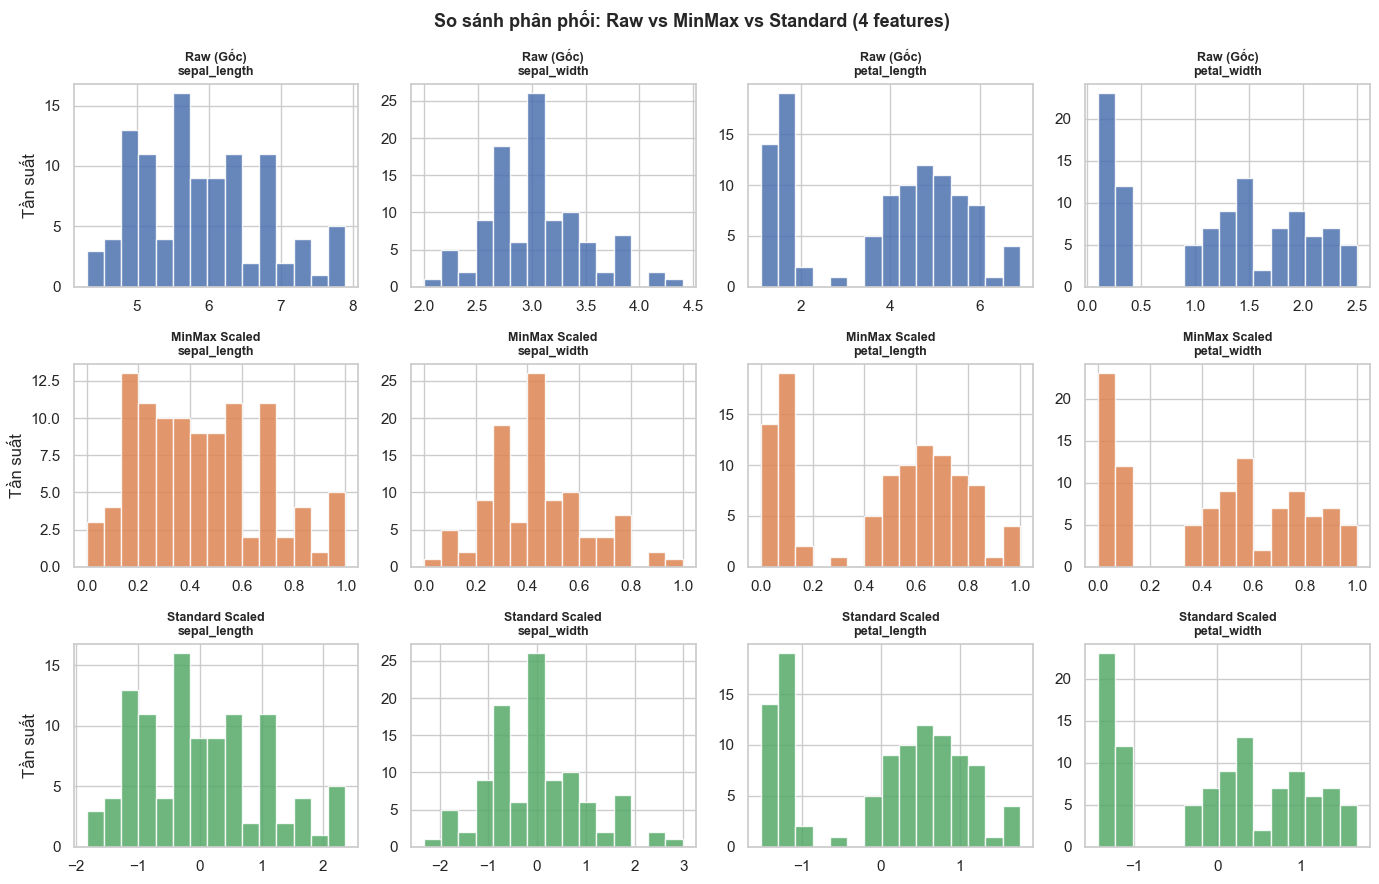

In [15]:
# Hiển thị tất cả 4 features
show_feats  = FEATURES
titles      = ['Raw (Gốc)', 'MinMax Scaled', 'Standard Scaled']
datasets    = [train_raw, train_mm, train_std]
row_colors  = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for row, (title, data, col) in enumerate(zip(titles, datasets, row_colors)):
    for c, feat in enumerate(show_feats):
        axes[row, c].hist(data[feat], bins=15, color=col, edgecolor='white', alpha=0.85)
        axes[row, c].set_title(f'{title}\n{feat}', fontsize=9, fontweight='bold')
        axes[row, c].set_ylabel('Tần suất' if c == 0 else '')

plt.suptitle('So sánh phân phối: Raw vs MinMax vs Standard (4 features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_scaling_compare.png'), bbox_inches='tight')
plt.show()

# 5. Ghi kết quả EDA vào Excel

In [16]:
timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# Sheet 1: Thông tin chung – lưu lịch sử mỗi lần chạy, không ghi đè
df_info = pd.DataFrame({
    'Thông tin': ['Thời gian chạy', 'File dữ liệu', 'Số dòng', 'Số cột',
                  'Số lớp', 'Missing values', 'Duplicates', 'Tỉ lệ split'],
    'Giá trị':  [timestamp, DATA_PATH,
                 df.shape[0], df.shape[1],
                 df['class'].nunique(), df.isnull().sum().sum(),
                 df.duplicated().sum(), f'Train {1-TEST_SIZE:.0%} / Test {TEST_SIZE:.0%}']
})

# Sheet 2: Thống kê mô tả
df_stats = df[FEATURES].describe().round(4).reset_index().rename(columns={'index': 'Thống kê'})

# Sheet 3: Missing values
df_miss = pd.DataFrame({
    'Cột':      df.columns,
    'Số thiếu': df.isnull().sum().values,
    '% thiếu':  (df.isnull().sum() / len(df) * 100).round(2).values
})

# Sheet 4: Phân phối lớp
df_class = df['class'].value_counts().reset_index()
df_class.columns = ['Lớp', 'Số lượng']
df_class['Tỉ lệ %'] = (df_class['Số lượng'] / len(df) * 100).round(2)

# Sheet 5: Train/Test split info
df_split = pd.DataFrame({
    'Tập':    ['Train (raw)', 'Test (raw)', 'Train (minmax)', 'Test (minmax)',
               'Train (standard)', 'Test (standard)'],
    'File':   [TRAIN_DATA_RAW, TEST_DATA_RAW, TRAIN_DATA_MM,
               TEST_DATA_MM, TRAIN_DATA_STD, TEST_DATA_STD],
    'Số mẫu': [len(X_train), len(X_test)] * 3,
})

# Ghi Excel – nối lịch sử vào sheet Thong_tin_chung, ghi đè các sheet còn lại
if os.path.exists(EDA_LOG):
    try:
        df_old     = pd.read_excel(EDA_LOG, sheet_name='Thong_tin_chung')
        df_history = pd.concat([df_old, df_info], ignore_index=True)
        is_new     = False
    except Exception:
        df_history = df_info
        is_new     = True
else:
    df_history = df_info
    is_new     = True

with pd.ExcelWriter(EDA_LOG, engine='openpyxl', mode='w') as writer:
    df_history.to_excel(writer, sheet_name='Thong_tin_chung',  index=False)
    df_stats.to_excel(writer,   sheet_name='Thong_ke_mo_ta',   index=False)
    df_miss.to_excel(writer,    sheet_name='Missing_Values',   index=False)
    df_class.to_excel(writer,   sheet_name='Phan_phoi_lop',    index=False)
    df_split.to_excel(writer,   sheet_name='Train_Test_Split', index=False)

label = '🆕 Tạo file mới' if is_new else '➕ Cập nhật file'
print(f'{label}: {os.path.basename(EDA_LOG)}')
print(f'⏱  Thời gian ghi: {timestamp}')
print('📋 Cấu trúc (5 sheets):')
from openpyxl import load_workbook as _lw
_wb = _lw(EDA_LOG)
for i, sh in enumerate(_wb.sheetnames):
    print(f'   Sheet {i+1}: {sh}')
_wb.close()

➕ Cập nhật file: iris_eda_log.xlsx
⏱  Thời gian ghi: 2026-04-03 14:20:35
📋 Cấu trúc (5 sheets):
   Sheet 1: Thong_tin_chung
   Sheet 2: Thong_ke_mo_ta
   Sheet 3: Missing_Values
   Sheet 4: Phan_phoi_lop
   Sheet 5: Train_Test_Split


# 6. Tổng kết EDA

In [17]:
print('=' * 58)
print('TỔNG KẾT EDA - IRIS DATASET')
print('=' * 58)
print(f'⏱  Thời gian hoàn thành: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'✅ Tổng mẫu          : {len(df)}')
print(f'✅ Số đặc trưng      : {len(FEATURES)}')
print(f'✅ Số lớp            : {df["class"].nunique()} ({list(df["class"].unique())})')
print(f'✅ Missing values    : {df.isnull().sum().sum()}')
print(f'✅ Duplicates        : {df.duplicated().sum()}')
print(f'✅ Train set         : {len(X_train)} mẫu')
print(f'✅ Test set          : {len(X_test)} mẫu')
print()
print('📁 Các file đã tạo trong exps_/')
print('   eda_log.xlsx           ← kết quả EDA (5 sheets)')
print('   train_raw.csv          ← train data gốc')
print('   test_raw.csv           ← test data gốc')
print('   train_minmax.csv       ← train MinMax')
print('   test_minmax.csv        ← test MinMax')
print('   train_standard.csv     ← train Standard')
print('   test_standard.csv      ← test Standard')
print()
print('📊 Biểu đồ đã lưu:')
print('   plot_class_distribution.png')
print('   plot_histogram.png')
print('   plot_boxplot.png')
print('   plot_violin.png')
print('   plot_mean_by_class.png')
print('   plot_correlation.png')
print('   plot_scaling_compare.png')
print('=' * 58)
print('➡ Bước tiếp theo: chạy 02_train.ipynb')

TỔNG KẾT EDA - IRIS DATASET
⏱  Thời gian hoàn thành: 2026-04-03 14:20:35
✅ Tổng mẫu          : 150
✅ Số đặc trưng      : 4
✅ Số lớp            : 3 (['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])
✅ Missing values    : 0
✅ Duplicates        : 3
✅ Train set         : 105 mẫu
✅ Test set          : 45 mẫu

📁 Các file đã tạo trong exps_/
   eda_log.xlsx           ← kết quả EDA (5 sheets)
   train_raw.csv          ← train data gốc
   test_raw.csv           ← test data gốc
   train_minmax.csv       ← train MinMax
   test_minmax.csv        ← test MinMax
   train_standard.csv     ← train Standard
   test_standard.csv      ← test Standard

📊 Biểu đồ đã lưu:
   plot_class_distribution.png
   plot_histogram.png
   plot_boxplot.png
   plot_violin.png
   plot_mean_by_class.png
   plot_correlation.png
   plot_scaling_compare.png
➡ Bước tiếp theo: chạy 02_train.ipynb
